In [1]:
import dill
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
import jax.numpy as jnp
import numpy as np
import pandas as pd
import statsmodels.api as sm

num_trials = 210 # 500, 1000, 2500, 5000
num_iters = 1500 # number of iterations for Gibbs sampler
burn_in = 500 # number of trials thrown away (make sure this is the same as in simulation script)
num_datasets = 50
num_subjects = 663
num_inputs = 3


true_mu_a = 0.98
true_sigma_a = 0.03
true_mu_w = jnp.array([0.0, 0.2, -0.1])
true_sigma_w = jnp.array([1.0, 1.0, 1.0])
true_mu_sigmasq = 0.2
true_beta_sigmasq = 0.5
true_sigma_mu_x = 0.5


In [2]:
sns.set_theme(style="ticks", context="paper",
              font="Arial",
              rc={"font.size": 20,
                "axes.titlesize": 20,
                "axes.labelsize": 20,
                "lines.linewidth": 1.5,
                "xtick.labelsize": 15,
                "ytick.labelsize": 15,
                "xtick.major.size": 5,
                "ytick.major.size": 5,
                "xtick.minor.size": 2,
                "ytick.minor.size": 2,
                "axes.spines.right": False,
                "axes.spines.top": False
        })

In [4]:
"""
Load in dill file (contains the environment when simulation ran on cluster computer)
Due to memory issues on the cluster computer the simulations for high trial counts (2500 and 5000)
had to be split up, simulating the 50 datasets in multiple runs (25/25, or 10/10/10/10/10), hence the multiple dill files.
"""

def load_dill_file(file_path):
    with open(file_path, 'rb') as file:
        list_of_variable_names = dill.load(file)  # Get the names of stored objects
        for variable_name in list_of_variable_names:
            globals()[variable_name] = dill.load(file)  # Get the objects themselves



wd = "./"

file_paths_mapping = {
    (210, 663): [wd + "210trials_663subjects.dil"]
}

which_file = file_paths_mapping.get((num_trials, num_subjects))

for file_path in which_file:
    load_dill_file(file_path)


# Get the file paths based on the number of trials and subjects
which_file = file_paths_mapping.get((num_trials, num_subjects))



# Load in the files
for file_path in which_file:
    load_dill_file(file_path)

Text(0.05, 0.75, 'mean r = 0.50 ± 0.00')

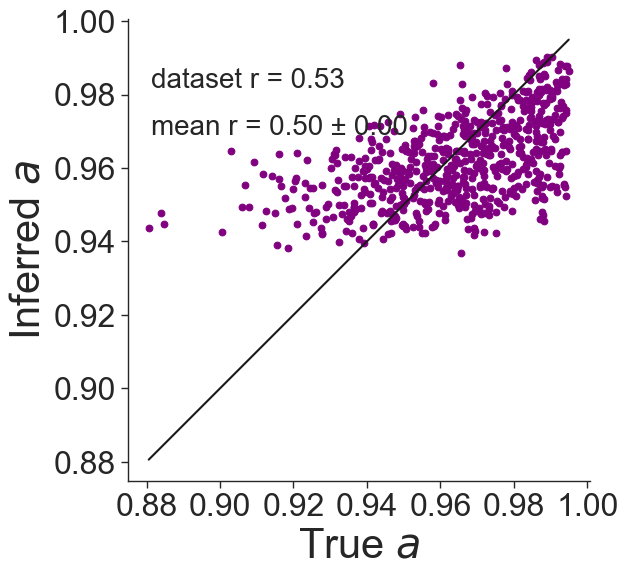

In [5]:
"""
Compare true and inferred estimates of a_i averaged over iterations (minus the burn-in) for all datasets
"""

dataset = 15

a_min = min(all_true_params[dataset]['a'].min(), jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0).min())
a_max = max(all_true_params[dataset]['a'].max(), jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0).max())

# calculate mean correlation over all datasets
all_r_a = []

for d in range(num_datasets):
    fitted_a = jnp.mean(all_posterior_samples_a[d][burn_in:], axis=0)
    r_d, _ = spearmanr(all_true_params[d]['a'], fitted_a)
    all_r_a.append(r_d)

mean_r_a = np.mean(all_r_a)
sem_r_a = np.std(all_r_a, ddof=1) / np.sqrt(num_datasets)

plt.figure(figsize=(8, 6))
plt.scatter(all_true_params[dataset]['a'], jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0), color="purple")
plt.plot([a_min, a_max], [a_min, a_max], '-k')
plt.xlabel("True $a$", size=30)
plt.ylabel("Inferred $a$",size=30)
plt.xticks(size=23)
plt.yticks(size=23)

#plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
# Correlatie van deze dataset
r, p = spearmanr(all_true_params[dataset]['a'],
                 jnp.mean(all_posterior_samples_a[dataset][burn_in:], axis=0))

# Voeg beide toe aan plot
plt.annotate(f'dataset r = {r:.2f}', xy=(0.05, 0.85), xycoords='axes fraction')
plt.annotate(f'mean r = {mean_r_a:.2f} ± {sem_r_a:.02f}', 
             xy=(0.05, 0.75), xycoords='axes fraction')
#plt.savefig("recovery_a_5000.png", transparent=True, dpi=600)


Text(0.05, 0.75, 'mean r = 0.52 ± 0.01')

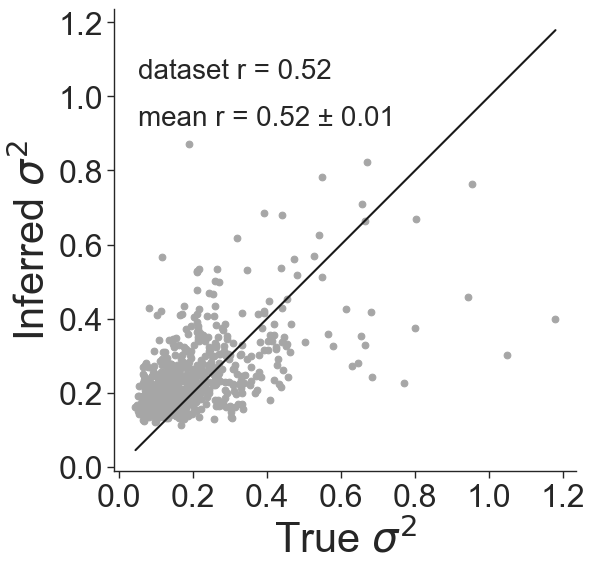

In [6]:
"""
Compare true and inferred estimates of sigma_sq averaged over iterations (minus the burn-in) for one example dataset
"""

dataset = 7

sigmasq_min = min(all_true_params[dataset]['sigmasq'].min(), jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0).min())
sigmasq_max = max(all_true_params[dataset]['sigmasq'].max(), jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0).max())

all_r_sigmasq = []

for d in range(num_datasets):
    fitted_sigmasq = jnp.mean(all_posterior_samples_sigmasq[d][burn_in:], axis=0)
    r_d, _ = spearmanr(all_true_params[d]['sigmasq'], fitted_sigmasq)
    all_r_sigmasq.append(r_d)

mean_r_sigmasq = np.mean(all_r_sigmasq)
sem_r_sigmasq = np.std(all_r_sigmasq, ddof=1) / np.sqrt(num_datasets)

plt.figure(figsize=(8, 6))
plt.scatter(all_true_params[dataset]['sigmasq'], jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0), color="#A6A6A6")
plt.plot([sigmasq_min, sigmasq_max], [sigmasq_min, sigmasq_max], '-k')
plt.xticks(size=23)
plt.yticks(size=23)
plt.xlabel("True $\sigma^2$", size=30)
plt.ylabel("Inferred $\sigma^2$",size=30)
#plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)
r, p = spearmanr(
    all_true_params[dataset]['sigmasq'],
    jnp.mean(all_posterior_samples_sigmasq[dataset][burn_in:], axis=0)
)
plt.annotate(f'dataset r = {r:.2f}', xy=(0.05, 0.85), xycoords='axes fraction')
plt.annotate(f'mean r = {mean_r_sigmasq:.2f} ± {sem_r_sigmasq:.02f}', 
             xy=(0.05, 0.75), xycoords='axes fraction')
#plt.savefig("recovery_sigmasq_5000.png", transparent=True, dpi=600)


Text(0.05, 0.75, 'mean r = 0.52 ± 0.00')

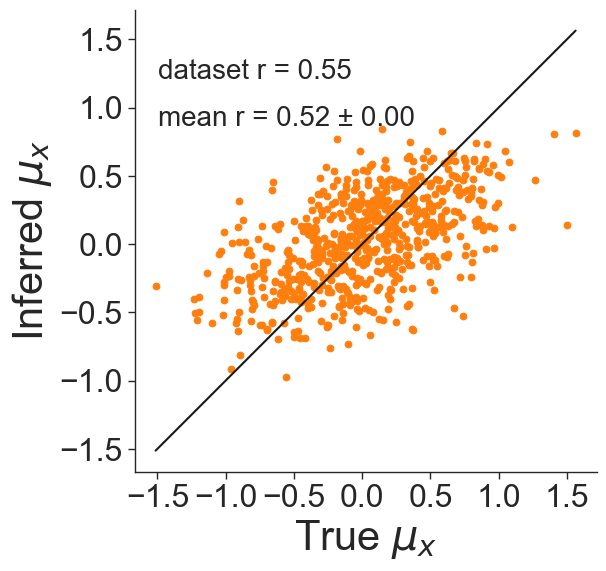

In [7]:
"""
Compare true and inferred estimates of mu_x averaged over iterations (minus the burn-in) for one example dataset
"""

dataset = 29

mu_x_min = min(all_true_params[dataset]['mu_x'].min(), jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0).min())
mu_x_max = max(all_true_params[dataset]['mu_x'].max(), jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0).max())

all_r_mu_x = []

for d in range(num_datasets):
    fitted_mu_x = jnp.mean(all_posterior_samples_mu_x[d][burn_in:], axis=0)
    r_d, _ = spearmanr(all_true_params[d]['mu_x'], fitted_mu_x)
    all_r_mu_x.append(r_d)

mean_r_mu_x = np.mean(all_r_mu_x)
sem_r_mu_x = np.std(all_r_mu_x, ddof=1) / np.sqrt(num_datasets)

plt.figure(figsize=(8, 6))
plt.scatter(all_true_params[dataset]['mu_x'], jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0), color="#FF7F0E")
plt.plot([mu_x_min, mu_x_max], [mu_x_min, mu_x_max], '-k')
plt.xticks(size=23)
plt.yticks(size=23)
plt.xlabel("True $\mu_x$", size=30)
plt.ylabel("Inferred $\mu_x$",size=30)
#plt.title(r"Dataset {:d}".format(dataset))
plt.gca().set_aspect(1.0)

r, p = spearmanr(
    all_true_params[dataset]['mu_x'],
    jnp.mean(all_posterior_samples_mu_x[dataset][burn_in:], axis=0)
)
plt.annotate(f'dataset r = {r:.2f}', xy=(0.05, 0.85), xycoords='axes fraction')
plt.annotate(f'mean r = {mean_r_mu_x:.2f} ± {sem_r_mu_x:.02f}', 
             xy=(0.05, 0.75), xycoords='axes fraction')
#plt.savefig("recovery_mu_x_5000.png", transparent=True, dpi=600)

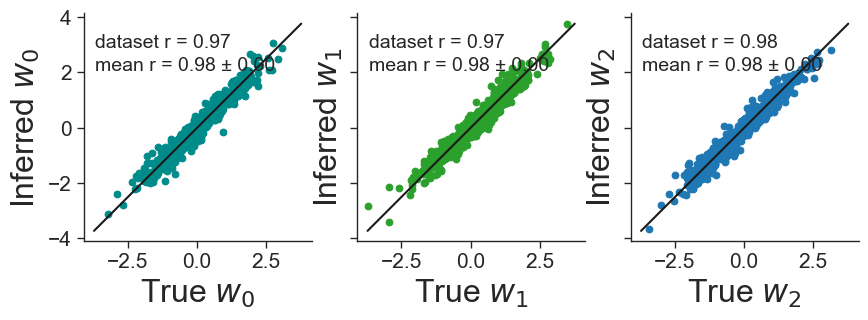

In [8]:
"""
Compare true and inferred estimates of w averaged over iterations (minus the burn-in) for one example dataset
"""

dataset = 49
colors = ['darkcyan', '#2ca02c', '#1f77b4', '#ff7f0e']
w_min = min(all_true_params[dataset]["w"].min(), jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,:], axis=0).min())
w_max = max(all_true_params[dataset]["w"].max(), jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,:], axis=0).max())

all_r_w = {0: [], 1: [], 2: []}

for d in range(num_datasets):
    fitted_w = jnp.mean(all_posterior_samples_w[d][burn_in:], axis=0)
    
    for i in range(num_inputs):
        r_d, _ = spearmanr(all_true_params[d]["w"][:, i], fitted_w[:, i])
        all_r_w[i].append(r_d)

mean_r_w = {i: np.mean(all_r_w[i]) for i in range(num_inputs)}
sem_r_w = {i: np.std(all_r_w[i], ddof=1) / np.sqrt(num_datasets) for i in range(num_inputs)}

fig, axs = plt.subplots(1, num_inputs, sharey=True, figsize=(10, 5))
#fig.suptitle(r"Dataset {:d}".format(dataset))
fig.subplots_adjust(top=1.3)

for d, ax in enumerate(axs):
    fitted = jnp.mean(all_posterior_samples_w[dataset][burn_in:,:,d], axis=0)

    ax.scatter(all_true_params[dataset]["w"][:, d], fitted, color=colors[d])
    ax.set_xlabel(r"True $w_{:d}$".format(d), size=23)
    ax.set_ylabel(r"Inferred $w_{:d}$".format(d), size=23)
    ax.plot([w_min, w_max], [w_min, w_max], '-k')
    ax.set_aspect(1.0)

    r, p = spearmanr(all_true_params[dataset]["w"][:, d], fitted)
    ax.annotate(f'dataset r = {r:.2f}', xy=(0.05, 0.85), xycoords='axes fraction', fontsize=14)
    ax.annotate(f'mean r = {mean_r_w[d]:.2f} ± {sem_r_w[d]:.02f}', 
                xy=(0.05, 0.75), xycoords='axes fraction', fontsize=14)

plt.savefig("recovery_w_5000.png", transparent=True, dpi=600)

Text(0.05, 0.92, 'r = 0.59')

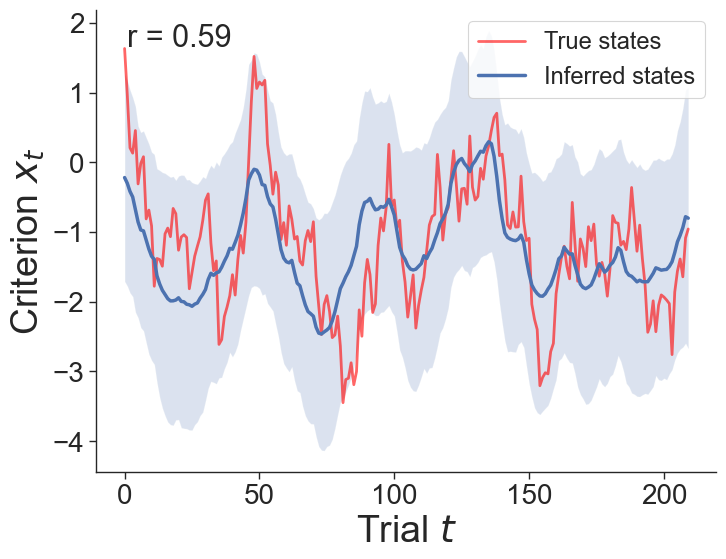

In [15]:
"""
Estimated criterion fluctuations for one example participant
"""

dataset = 49
subject = 663

plt.figure(figsize=(8, 6))
plt.plot(all_true_states[dataset][subject], label="True states", linewidth=2, color='red', alpha=.6)
plt.plot(all_posterior_samples_states[dataset][subject], label="Inferred states", linewidth=2.5)
plt.fill_between(jnp.arange(num_trials),
          all_posterior_samples_states[dataset][subject] - 2 * all_posterior_samples_states_sd[dataset][subject],
          all_posterior_samples_states[dataset][subject] + 2 * all_posterior_samples_states_sd[dataset][subject], alpha=0.2)
plt.xlabel("Trial $t$", fontsize=27)
plt.ylabel("Criterion $x_t$", fontsize=27)
plt.xticks(size=20)
plt.yticks(size=20)
#plt.ylim(-5.5,5.5)
#plt.title(r"Subject {:d}".format(subject))
plt.legend(loc='upper right', fontsize=17)
r, p = spearmanr(all_true_states[dataset][subject], all_posterior_samples_states[dataset][subject])
plt.annotate('r = {:.2f}'.format(r), xy=(0.05, 0.92), xycoords='axes fraction', fontsize=22)

#plt.savefig("estimated_criterion.png", transparent=True, dpi=600)

Overall mean criterion recovery: r = 0.778 ± 0.001
Dataset 7 mean: r = 0.775
Dataset 7 median: r = 0.804


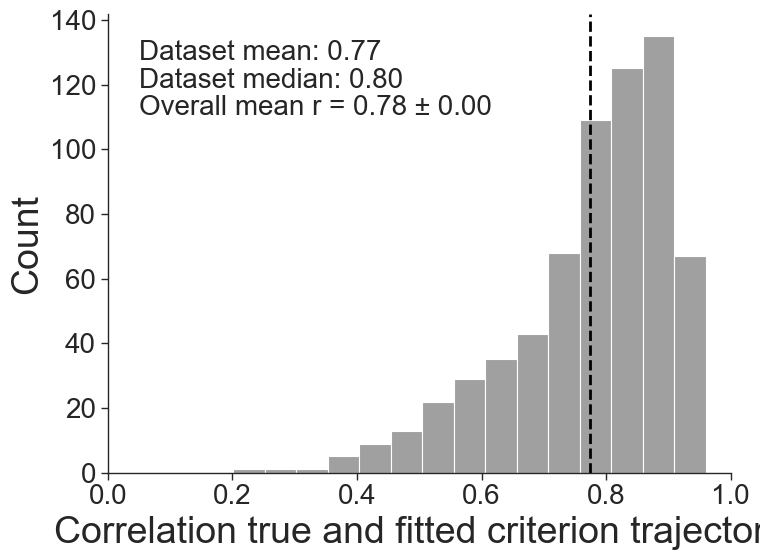

In [11]:
# %%
"""
Recovery criterion fluctuations one example dataset
+ overall mean recovery across all datasets
"""

dataset = 7

# ------------------------------------------------------------
# 1. Calculate mean criterion recovery over all datasets
# ------------------------------------------------------------

average_recovery_states_all_datasets = []
median_recovery_states_all_datasets = []

for d in range(num_datasets):
    correlations_d = []

    for subject in range(num_subjects):
        r, _ = spearmanr(
            all_true_states[d][subject],
            all_posterior_samples_states[d][subject]
        )
        correlations_d.append(r)

    correlations_d = jnp.array(correlations_d)

    average_recovery_states_all_datasets.append(jnp.mean(correlations_d))
    median_recovery_states_all_datasets.append(jnp.median(correlations_d))

average_recovery_states_all_datasets = jnp.array(average_recovery_states_all_datasets)
median_recovery_states_all_datasets = jnp.array(median_recovery_states_all_datasets)

overall_mean_r = jnp.mean(average_recovery_states_all_datasets)
overall_sem_r = jnp.std(average_recovery_states_all_datasets, ddof=1) / jnp.sqrt(num_datasets)

print(f"Overall mean criterion recovery: r = {overall_mean_r:.3f} ± {overall_sem_r:.3f}")


# ------------------------------------------------------------
# 2. calculate correlations for one example dataset
# ------------------------------------------------------------

correlations_inferred_and_fitted_states = []

for subject in range(num_subjects):
    r, _ = spearmanr(
        all_true_states[dataset][subject],
        all_posterior_samples_states[dataset][subject]
    )
    correlations_inferred_and_fitted_states.append(r)

correlations_inferred_and_fitted_states = jnp.array(correlations_inferred_and_fitted_states)

mean_value = jnp.mean(correlations_inferred_and_fitted_states)
median_value = jnp.median(correlations_inferred_and_fitted_states)

print(f"Dataset {dataset} mean: r = {mean_value:.3f}")
print(f"Dataset {dataset} median: r = {median_value:.3f}")


# ------------------------------------------------------------
# 3. Plot histogram
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

sns.histplot(
    data=np.array(correlations_inferred_and_fitted_states),
    bins=15,
    color="gray"
)

plt.axvline(
    mean_value,
    color="black",
    linestyle="--",
    linewidth=2
)

plt.annotate(
    f"Dataset mean: {mean_value:.2f}",
    xy=(0.05, 0.90),
    xycoords="axes fraction",
    fontsize=20
)

plt.annotate(
    f"Dataset median: {median_value:.2f}",
    xy=(0.05, 0.84),
    xycoords="axes fraction",
    fontsize=20
)

plt.annotate(
    f"Overall mean r = {overall_mean_r:.2f} ± {overall_sem_r:.02f}",
    xy=(0.05, 0.78),
    xycoords="axes fraction",
    fontsize=20
)

plt.xticks(size=20)
plt.yticks(size=20)

plt.xlabel("Correlation true and fitted criterion trajectory", fontsize=27)
plt.ylabel("Count", fontsize=27)

plt.xlim(0, 1)

plt.tight_layout()
# plt.savefig("recovery_criterion_trajectory.png", transparent=True, dpi=600)
plt.show()